In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")

Libraries loaded.


In [2]:
# Load datasets
df_roman = pd.read_csv('../data/processed/rufnd_features.csv')
df_urdu = pd.read_csv('../data/processed/urdu_news_features.csv')

# Fix label whitespace
df_urdu['label'] = df_urdu['label'].str.strip()
df_roman['label'] = df_roman['label'].str.strip()

# Load vectorizers
with open('../models/tfidf_roman.pkl', 'rb') as f:
    tfidf_roman = pickle.load(f)

with open('../models/tfidf_urdu.pkl', 'rb') as f:
    tfidf_urdu = pickle.load(f)

# Load best models
with open('../models/best_model_roman_urdu.pkl', 'rb') as f:
    model_roman = pickle.load(f)

with open('../models/best_model_urdu.pkl', 'rb') as f:
    model_urdu = pickle.load(f)

print("All models and datasets loaded.")
print(f"RUFND: {df_roman.shape[0]} rows")
print(f"Urdu News: {df_urdu.shape[0]} rows")

All models and datasets loaded.
RUFND: 3800 rows
Urdu News: 10440 rows


In [3]:
# Cross evaluation
# Test 1: Urdu News model on Roman Urdu data
X_roman_for_urdu = tfidf_urdu.transform(df_roman['text'])
y_roman = df_roman['label']
y_pred_urdu_on_roman = model_urdu.predict(X_roman_for_urdu)

f1_urdu_on_roman = f1_score(y_roman, y_pred_urdu_on_roman, pos_label='fake', average='binary')

# Test 2: Roman Urdu model on Urdu News data
X_urdu_for_roman = tfidf_roman.transform(df_urdu['text'])
y_urdu = df_urdu['label']
y_pred_roman_on_urdu = model_roman.predict(X_urdu_for_roman)

f1_roman_on_urdu = f1_score(y_urdu, y_pred_roman_on_urdu, pos_label='fake', average='binary')

print("=== Cross Evaluation Results ===")
print(f"\nUrdu News model tested on Roman Urdu data:")
print(f"F1 (fake class): {f1_urdu_on_roman:.4f}")

print(f"\nRoman Urdu model tested on Urdu News data:")
print(f"F1 (fake class): {f1_roman_on_urdu:.4f}")

=== Cross Evaluation Results ===

Urdu News model tested on Roman Urdu data:
F1 (fake class): 0.6803

Roman Urdu model tested on Urdu News data:
F1 (fake class): 0.0793


In [4]:
print("=== Urdu News model on Roman Urdu data ===")
print(classification_report(y_roman, y_pred_urdu_on_roman))

print("=== Roman Urdu model on Urdu News data ===")
print(classification_report(y_urdu, y_pred_roman_on_urdu))

=== Urdu News model on Roman Urdu data ===
              precision    recall  f1-score   support

        fake       0.53      0.96      0.68      2000
        real       0.47      0.04      0.07      1800

    accuracy                           0.52      3800
   macro avg       0.50      0.50      0.37      3800
weighted avg       0.50      0.52      0.39      3800

=== Roman Urdu model on Urdu News data ===
              precision    recall  f1-score   support

        fake       0.52      0.04      0.08      4101
        real       0.61      0.97      0.75      6339

    accuracy                           0.61     10440
   macro avg       0.57      0.51      0.42     10440
weighted avg       0.58      0.61      0.49     10440



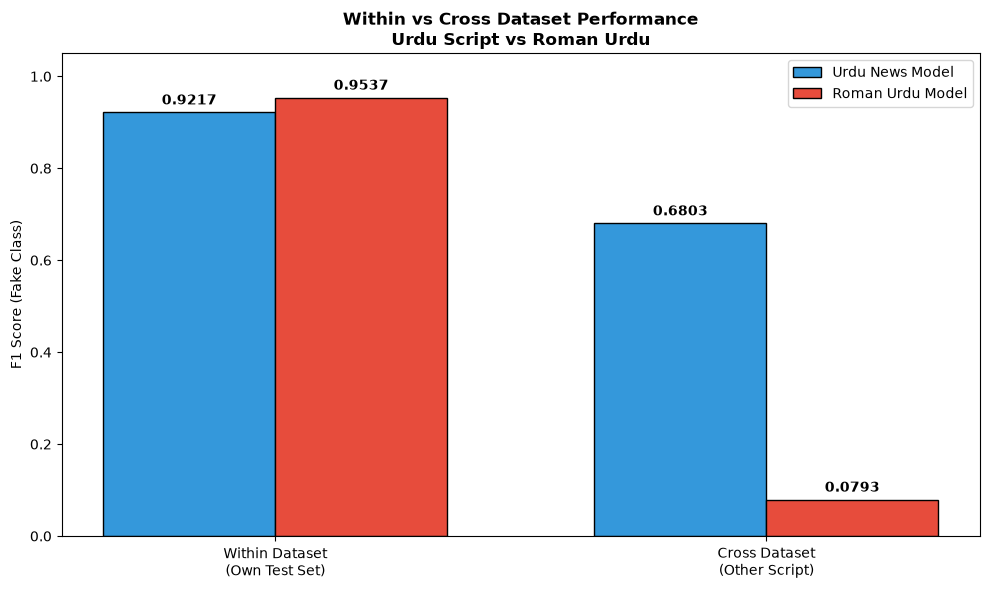

Saved.


In [5]:
# Performance comparison chart
categories = ['Within Dataset\n(Own Test Set)', 'Cross Dataset\n(Other Script)']

urdu_scores = [0.9217, f1_urdu_on_roman]
roman_scores = [0.9537, f1_roman_on_urdu]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, urdu_scores, width, label='Urdu News Model',
               color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, roman_scores, width, label='Roman Urdu Model',
               color='#e74c3c', edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('F1 Score (Fake Class)')
ax.set_title('Within vs Cross Dataset Performance\nUrdu Script vs Roman Urdu', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../results/figures/cross_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [6]:
# Final summary table
summary = pd.DataFrame({
    'Model': ['Urdu News Model', 'Roman Urdu Model'],
    'Own Test F1': [0.9217, 0.9537],
    'Cross Dataset F1': [f1_urdu_on_roman, f1_roman_on_urdu],
    'Performance Drop': [
        round(0.9217 - f1_urdu_on_roman, 4),
        round(0.9537 - f1_roman_on_urdu, 4)
    ]
})

print("=== Cross Evaluation Summary ===")
print(summary.to_string(index=False))

summary.to_csv('../results/cross_evaluation_summary.csv', index=False)
print("\nSummary saved.")

=== Cross Evaluation Summary ===
           Model  Own Test F1  Cross Dataset F1  Performance Drop
 Urdu News Model       0.9217          0.680332            0.2414
Roman Urdu Model       0.9537          0.079333            0.8744

Summary saved.
